# Importo librerías

In [122]:
import os
import numpy as np
from numpy import array
import pandas as pd  ## Esta librería se utiliza para manipulacipon de datos. Facilita el manejo de archivos CSV y permite leer dataset que estan en colab de forma directa o en alguna url especificada
import matplotlib.pyplot as plt
import pickle
import seaborn as sn

## Tensorflow + Keras libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense,Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.models import Model
import tensorflow_model_optimization as tfmot

##Prunnig
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning

## Quantization
from qkeras import *

## Datasets
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import fashion_mnist

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

## Metricas
from sklearn.metrics import ( accuracy_score, classification_report, confusion_matrix,  ConfusionMatrixDisplay)

## Estadísticas
from qkeras.qtools import run_qtools
from qkeras.qtools import settings as qtools_settings

In [123]:
# ESTO ME TIENE QUE DEVOLVER LA VERSION DE PYTHON, TENSORFLOW 2.12 Y QUE NO HAY KERAS (PORQUE VIENE INSTADO CON TESNROFLOW EN ESA VERSION)

import sys
print("Python version:", sys.version) # Versión de Python
print("TensorFlow version:", tf.__version__) # Versión de TensorFlow
print("Keras version:", keras.__version__) # Versión de Keras

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
TensorFlow version: 2.12.0
Keras version: 2.12.0


# Importo archivo

In [124]:
ruta_archivo = r"C:\Users\manue\Posgrado\Cursos\2026\EAMTA\ProyectoFinal\archive\RML2016.10a_dict.pkl"
with open(ruta_archivo, 'rb') as f:
    dataset = pickle.load(f, encoding='latin1')


# Diccionario de tuplas (Modulación, SNR)
print(list(dataset.keys())[:5])
print((dataset['QPSK', 2]).shape)
print((dataset['QPSK', 2][0]).shape)

[('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8)]
(1000, 2, 128)
(2, 128)


# Desarrollo
## Análisis del dataset

Ejemplo de llaves: [('QAM16', 2), ('QAM16', -20), ('PAM4', -6), ('WBFM', -18), ('AM-DSB', 16), ('CPFSK', 10), ('WBFM', 6), ('BPSK', 4), ('BPSK', -2), ('QPSK', -20), ('CPFSK', -8), ('AM-SSB', 6), ('QAM64', -20), ('QAM16', 12), ('GFSK', -20), ('AM-SSB', -12), ('CPFSK', 0), ('AM-DSB', 6), ('BPSK', -16), ('QPSK', -6), ('8PSK', -12), ('CPFSK', -18), ('BPSK', -10), ('QPSK', 8), ('PAM4', 14), ('AM-DSB', -10), ('GFSK', 12), ('QAM64', 2), ('WBFM', -4), ('AM-SSB', -18), ('QAM64', -4), ('GFSK', -4), ('AM-DSB', 8), ('PAM4', -16), ('QPSK', -16), ('BPSK', 16), ('8PSK', -8), ('CPFSK', 16), ('WBFM', 0), ('QPSK', 6), ('BPSK', 14)]
Se tienen 220 grupos de señales (modulación, SNR).
Se tienen 1000 señales para cada grupo.


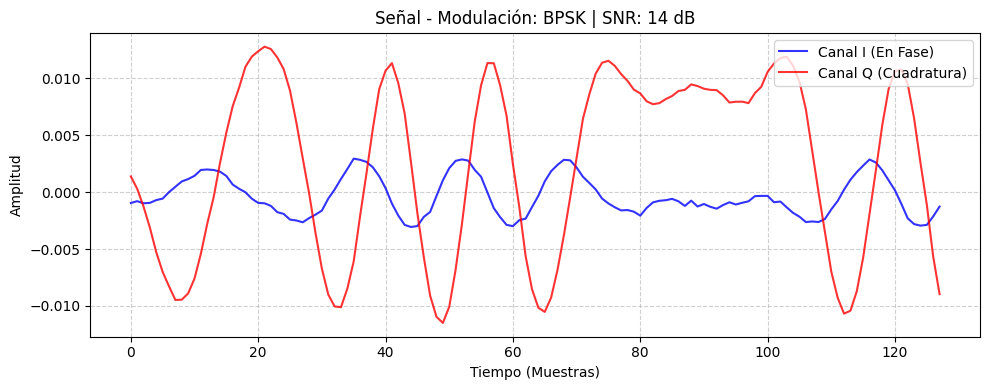

In [125]:
# Tomamos la primera llave del diccionario para ver qué contiene
llave_ejemplo = list(dataset.keys())[49]
modulacion, snr = llave_ejemplo

print("Ejemplo de llaves:", list(dataset.keys())[9:50])

print("Se tienen", len(dataset), "grupos de señales (modulación, SNR).")
print("Se tienen", len(dataset[llave_ejemplo]), "señales para cada grupo.")

# Extraemos todas las señales que corresponden a esa llave
# Esto será un array de forma (N=1000, 2, 128)
senales = dataset[llave_ejemplo]

# Tomamos solo la primera señal de ese grupo
# Ahora tenemos un array de forma (2, 128)
una_senal = senales[0]

# Separamos los dos canales (I y Q)
canal_I = una_senal[0, :] # Fila 0, todas las columnas
canal_Q = una_senal[1, :] # Fila 1, todas las columnas

# Graficamos los canales I y Q para esa señal específica
plt.figure(figsize=(10, 4))
plt.plot(canal_I, label='Canal I (En Fase)', color='blue', alpha=0.8)
plt.plot(canal_Q, label='Canal Q (Cuadratura)', color='red', alpha=0.8)

# Le ponemos título dinámico según la modulación y el SNR
# Nota: a veces la modulación viene como bytes (ej. b'QPSK'), 
# str() o .decode() lo arregla para que el título se vea limpio.
nombre_modulacion = modulacion.decode('utf-8') if isinstance(modulacion, bytes) else modulacion

plt.title(f'Señal - Modulación: {nombre_modulacion} | SNR: {snr} dB')
plt.xlabel('Tiempo (Muestras)')
plt.ylabel('Amplitud')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Mostrar el gráfico en VS Code
plt.show()

## Preprocesamiento

### Extracción y separación de datos

In [126]:
# Listas vacías para guardar los datos
X = [] # Lista para senales
Y = [] # Lista para etiquetas (modulacion)
snrs = [] # Valores SNR correspondientes a cada señal

# Se recorre el diccionario para desarmarlo
cont = 0
for llave, senales in dataset.items(): # key -> llave : value -> senales
    modulacion, snr = llave
    nombre_mod = modulacion.decode('utf-8') if isinstance(modulacion, bytes) else modulacion
    
    # Se agrega cada senal individual y su etiqueta a las listas
    for senal in senales:
        X.append(senal)
        Y.append(nombre_mod)
        snrs.append(snr)


# Pasamos a numpy
X = np.array(X)
Y = np.array(Y)
snrs = np.array(snrs)

# Se separa para entrenamiento y prueba (80% train, 20% test)
X_train, X_test, Y_train, Y_test, snrs_train, snrs_test = train_test_split(X, Y, snrs, test_size=0.2, random_state=42)
X_train = np.array(X_train)
X_test  = np.array(X_test)
Y_train = np.array(Y_train)
Y_test  = np.array(Y_test)
snrs_train = np.array(snrs_train)
snrs_test = np.array(snrs_test)

# Pasaje de etiquetas a números (encoding)
# Creamos el codificador
encoder = LabelEncoder()

# Convertimos los textos de entrenamiento y prueba a números enteros (0, 1, 2... 10)
Y_train_num = encoder.fit_transform(Y_train)
# Importante usar solo 'transform' en test para mantener la misma correspondencia
Y_test_num = encoder.transform(Y_test)

print("Clases originales:", encoder.classes_)
print("Ejemplo de Y_train en texto:", Y_train[:5])
print("Ejemplo de Y_train en números:", Y_train_num[:5])

Clases originales: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']
Ejemplo de Y_train en texto: ['QAM64' 'CPFSK' 'WBFM' 'AM-DSB' 'WBFM']
Ejemplo de Y_train en números: [ 8  4 10  1 10]


### Inspección del Dataset luego del preprocesamiento

X_train shape: (176000, 2, 128)
Y_train shape: (176000,)
X_test shape: (44000, 2, 128)
Y_test shape: (44000,)
Clases: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']
Cantidad de clases: 11


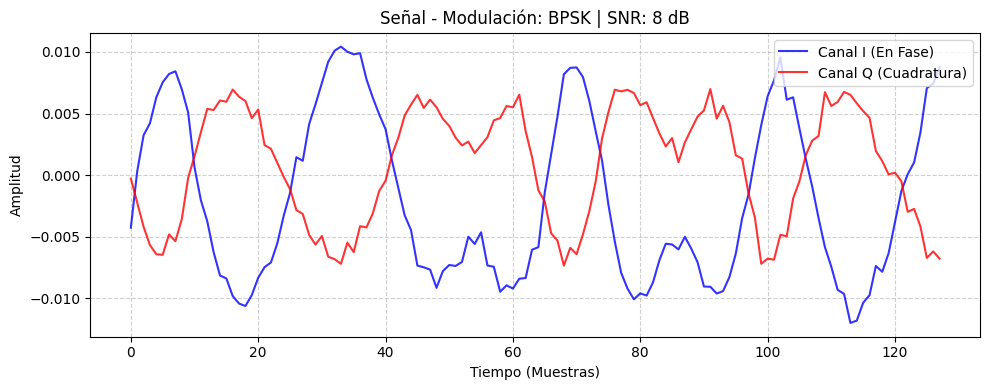

In [127]:
N = 10167

canal_I = X_train[N][0, :] # Canal I (En Fase)
canal_Q = X_train[N][1, :] # Canal Q (Cuadratura)

plt.figure(figsize=(10, 4))
plt.plot(canal_I, label='Canal I (En Fase)', color='blue', alpha=0.8)
plt.plot(canal_Q, label='Canal Q (Cuadratura)', color='red', alpha=0.8)
plt.title(f'Señal - Modulación: {Y_train[N]} | SNR: {snrs_train[N]} dB')
plt.xlabel('Tiempo (Muestras)')
plt.ylabel('Amplitud')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# "Forma" de la variable x_train.
print("X_train shape:", X_train.shape)

# "Forma" de la variable x_train.
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)


clases = np.unique(Y_train)
print("Clases:", clases)
print("Cantidad de clases:", len(clases))

### Normalización

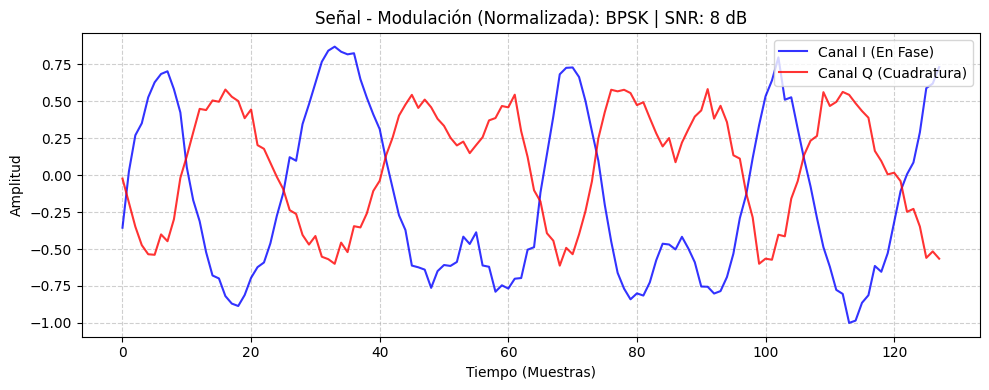

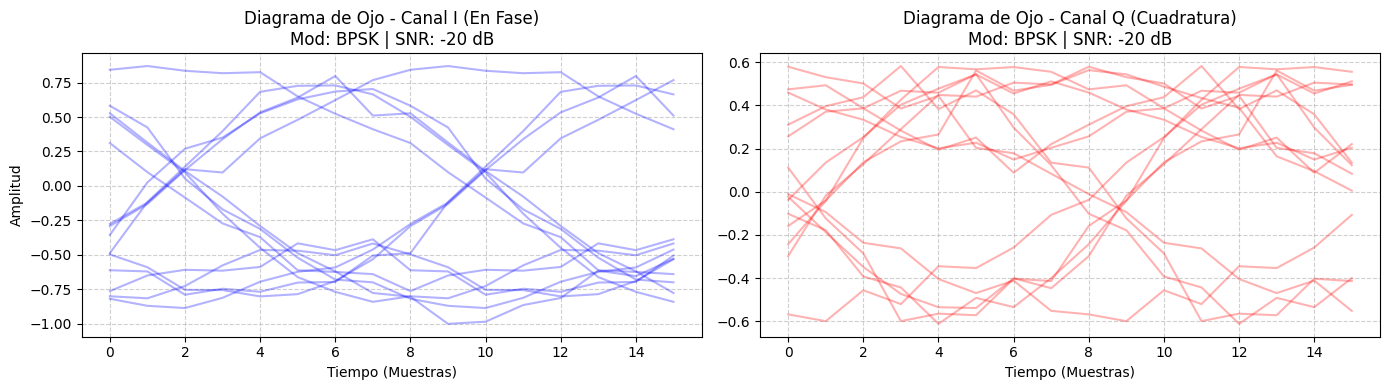

In [128]:
N = 10167

X_train_norm = []
for i in range(X_train.shape[0]):
    max_val = 0
    if X_train[i].max() > -X_train[i].min():
        max_val = X_train[i].max()
    else:
        max_val = -X_train[i].min()
    X_train_norm.append(X_train[i] / max_val if max_val != 0 else X_train[i])
    
X_test_norm = []
for i in range(X_test.shape[0]):
    max_val = 0
    if X_test[i].max() > -X_test[i].min():
        max_val = X_test[i].max()
    else:
        max_val = -X_test[i].min()
    X_test_norm.append(X_test[i] / max_val if max_val != 0 else X_test[i])

X_train_norm = np.array(X_train_norm)
X_test_norm  = np.array(X_test_norm)

canal_I_norm = X_train_norm[N][0, :] # Canal I (En Fase)
canal_Q_norm = X_train_norm[N][1, :] # Canal Q (Cuadratura)

plt.figure(figsize=(10, 4))
plt.plot(canal_I_norm, label='Canal I (En Fase)', color='blue', alpha=0.8)
plt.plot(canal_Q_norm, label='Canal Q (Cuadratura)', color='red', alpha=0.8)
plt.title(f'Señal - Modulación (Normalizada): {Y_train[N]} | SNR: {snrs_train[N]} dB')
plt.xlabel('Tiempo (Muestras)')
plt.ylabel('Amplitud')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()






# --- PARÁMETROS DEL DIAGRAMA DE OJO ---
sps = 8
simbolos_por_trazo = 2
ventana = sps * simbolos_por_trazo

# Creamos la figura con dos gráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Bucle para recortar y superponer los fragmentos de la señal
# Saltamos de 'sps' en 'sps' para alinear los símbolos correctamente
for i in range(0, len(canal_I_norm) - ventana, sps):
    
    # Graficamos el Canal I
    ax1.plot(canal_I_norm[i:i + ventana], color='blue', alpha=0.3)
    
    # Graficamos el Canal Q
    ax2.plot(canal_Q_norm[i:i + ventana], color='red', alpha=0.3)

# --- FORMATO DEL CANAL I ---
ax1.set_title(f'Diagrama de Ojo - Canal I (En Fase)\nMod: {Y_train[N]} | SNR: {snrs[N]} dB')
ax1.set_xlabel('Tiempo (Muestras)')
ax1.set_ylabel('Amplitud')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- FORMATO DEL CANAL Q ---
ax2.set_title(f'Diagrama de Ojo - Canal Q (Cuadratura)\nMod: {Y_train[N]} | SNR: {snrs[N]} dB')
ax2.set_xlabel('Tiempo (Muestras)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Diseñar una red neuronal

## CNN

In [129]:
# Dimensiones de entrada
w = X_train_norm.shape[1]
h = X_train_norm.shape[2]
input_shape = (w, h, 1)

# Número de clases
n_classes = 11

inputs = layers.Input(shape=(w, h), name='input_layer')
x = layers.Permute((2, 1), name='permutar_dimensiones')(inputs)

# --- CAPA CONVOLUCIONAL INICIAL ---
# Expandimos la señal antes de entrar a los bloques residuales
x = layers.Conv1D(filters=64, kernel_size=7, padding='same', name='conv_inicial')(x)
x = layers.BatchNormalization(name='bn_inicial')(x)
x = layers.Activation('relu', name='relu_inicial')(x)

# ==========================================
#        BLOQUE RESIDUAL 1
# ==========================================
# 1. Guardamos la entrada original del bloque
res_1 = x 

# 2. Rama principal (aprende los patrones complejos)
x = layers.Conv1D(filters=64, kernel_size=5, padding='same', name='res1_conv1')(x)
x = layers.BatchNormalization(name='res1_bn1')(x)
x = layers.Activation('relu', name='res1_relu')(x)

x = layers.Conv1D(filters=64, kernel_size=5, padding='same', name='res1_conv2')(x)
x = layers.BatchNormalization(name='res1_bn2')(x)

# 3. CONEXIÓN RESIDUAL: Sumamos la entrada original a la salida de la rama
x = layers.Add(name='res1_add')([x, res_1])
x = layers.Activation('relu', name='res1_salida')(x)

# 4. Reducimos la dimensionalidad después de la suma
x = layers.MaxPooling1D(pool_size=2, name='res1_pool')(x)


# ==========================================
#        BLOQUE RESIDUAL 2 (Más profundo)
# ==========================================
# Como vamos a aumentar los filtros a 128, necesitamos que la conexión 
# residual también tenga 128 filtros para poder sumarlas.
res_2 = layers.Conv1D(filters=128, kernel_size=1, padding='same', name='res2_adaptador')(x)

# Rama principal
x = layers.Conv1D(filters=128, kernel_size=3, padding='same', name='res2_conv1')(x)
x = layers.BatchNormalization(name='res2_bn1')(x)
x = layers.Activation('relu', name='res2_relu')(x)

x = layers.Conv1D(filters=128, kernel_size=3, padding='same', name='res2_conv2')(x)
x = layers.BatchNormalization(name='res2_bn2')(x)

# Suma y salida
x = layers.Add(name='res2_add')([x, res_2])
x = layers.Activation('relu', name='res2_salida')(x)
x = layers.MaxPooling1D(pool_size=2, name='res2_pool')(x)


# --- CLASIFICADOR FINAL ---
x = layers.GlobalAveragePooling1D(name='gap_final')(x)
x = layers.Dropout(0.5, name='dropout_final')(x)
outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)

# Crear el modelo funcional
model_cnn = Model(inputs=inputs, outputs=outputs, name='CNN_1D_RadioML')

# Resumen del modelo
model_cnn.summary()

Model: "CNN_1D_RadioML"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_layer (InputLayer)       [(None, 2, 128)]     0           []                               
                                                                                                  
 permutar_dimensiones (Permute)  (None, 128, 2)      0           ['input_layer[0][0]']            
                                                                                                  
 conv_inicial (Conv1D)          (None, 128, 64)      960         ['permutar_dimensiones[0][0]']   
                                                                                                  
 bn_inicial (BatchNormalization  (None, 128, 64)     256         ['conv_inicial[0][0]']           
 )                                                                                   

### Compilación

In [130]:
##Learning Rate Scheduling: Esta es una técnica para variar el learning rate de forma autómatica.
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',   # mira el error en validación
    factor=0.5,           # reduce el LR a la mitad
    patience=2,           # espera 2 épocas sin mejora
    min_lr=1e-6,          # límite inferior
    verbose=1
)

In [131]:
##Early Stopping: Esto se agrega para obteenr una parada autómatica cuando el modelo ya no aprende más. Evita el overfititing
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

#monitor='val_loss': mira el error en validación
#patience=5: espera 5 épocas sin mejora antes de parar
#restore_best_weights=True: se queda con el mejor modelo, no el último

In [132]:
lr = 0.01  # Valor inicial que tome el learning rate
op = Adam(lr)  # Se podrían utilizar otros optimizadores

model_cnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=op,
    metrics=['accuracy']
)

## Entrenamiento

In [ ]:
# Asegurarse de que X_train_norm tenga la forma correcta para Conv2D (batch, height, width, channels)
X_train_norm_reshaped = X_train_norm.reshape(X_train_norm.shape[0], w, h, 1)

history_cnn = model_cnn.fit(
    X_train_norm_reshaped,
    Y_train_num,
    epochs=40, # Puedes ajustar el número de épocas
    batch_size=32, # Puedes ajustar el tamaño del lote
    validation_split=0.2, # Usar un 20% para validación
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/40
4400/4400 [==============================] - 83s 19ms/step - loss: 1.4542 - accuracy: 0.4539 - val_loss: 1.2474 - val_accuracy: 0.5181 - lr: 0.0100
Epoch 2/40
4400/4400 [==============================] - 82s 19ms/step - loss: 1.3109 - accuracy: 0.5045 - val_loss: 1.2285 - val_accuracy: 0.5287 - lr: 0.0100
Epoch 3/40
4400/4400 [==============================] - 78s 18ms/step - loss: 1.2857 - accuracy: 0.5140 - val_loss: 1.2119 - val_accuracy: 0.5433 - lr: 0.0100
Epoch 4/40
4400/4400 [==============================] - 80s 18ms/step - loss: 1.2696 - accuracy: 0.5210 - val_loss: 1.2046 - val_accuracy: 0.5453 - lr: 0.0100
Epoch 5/40
4400/4400 [==============================] - 81s 18ms/step - loss: 1.2601 - accuracy: 0.5247 - val_loss: 1.2151 - val_accuracy: 0.5495 - lr: 0.0100
Epoch 6/40
4400/4400 [==============================] - 81s 18ms/step - loss: 1.2544 - accuracy: 0.5264 - val_loss: 1.1902 - val_accuracy: 0.5450 - lr: 0.0100
Epoch 7/40
4400/4400 [========================

### Evaluación durante el entrenamiento

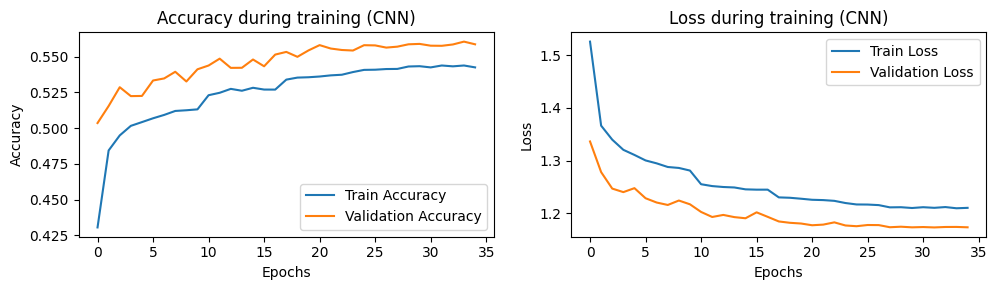

In [89]:
plt.figure(figsize=(10,3))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy during training (CNN)')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss during training (CNN)')
plt.legend()

plt.tight_layout()
plt.show()


### Evaluación del Modelo

In [90]:
X_test_norm_reshaped = X_test_norm.reshape(X_test_norm.shape[0], w, h, 1)

# Evaluación del modelo
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test_norm, Y_test_num)
print(f"\nTest accuracy (CNN): {test_acc_cnn:.4f}")

1375/1375 [==============================] - 4s 2ms/step - loss: 1.1792 - accuracy: 0.5578

Test accuracy (CNN): 0.5578


### Métricas

In [91]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score

y_pred = model_cnn.predict(X_test_norm)
y_pred_labels = np.argmax(y_pred, axis=1)

report_classification = classification_report(Y_test_num, y_pred_labels, digits=4) #, output_dict=True

print(report_classification)
print('Accuracy avg     %.4f' % test_acc_cnn)

1375/1375 [==============================] - 3s 2ms/step
              precision    recall  f1-score   support

           0     0.7381    0.5206    0.6105      3990
           1     0.5634    0.6407    0.5996      4086
           2     0.2584    0.9501    0.4063      4005
           3     0.7284    0.5933    0.6540      4018
           4     0.7798    0.6133    0.6866      3995
           5     0.8441    0.6181    0.7136      3967
           6     0.9006    0.6474    0.7533      4004
           7     0.5115    0.2772    0.3596      3921
           8     0.5854    0.4905    0.5338      3955
           9     0.7767    0.5497    0.6437      4088
          10     0.6921    0.2241    0.3386      3971

    accuracy                         0.5578     44000
   macro avg     0.6708    0.5568    0.5727     44000
weighted avg     0.6710    0.5578    0.5734     44000

Accuracy avg     0.5578


### Matriz de confusión

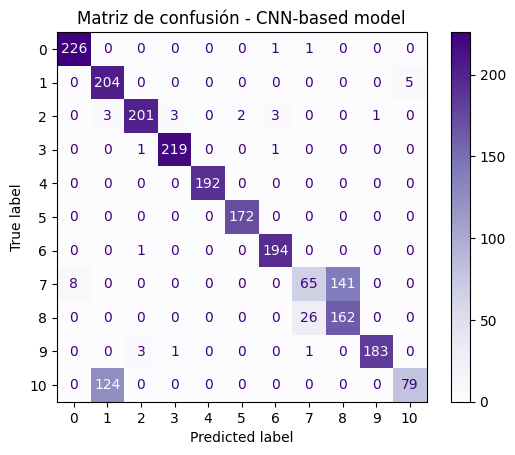

In [92]:
snr = 10
indices = np.where(snrs_test == snr)[0]
    
cm = confusion_matrix(Y_test_num[indices], y_pred_labels[indices])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Matriz de confusión - CNN-based model')
plt.show()

### Gráfico de precisión en función de la SNR

Evaluando modelo por nivel de SNR...
SNR: -20 dB | Accuracy: 8.43%
SNR: -18 dB | Accuracy: 8.62%
SNR: -16 dB | Accuracy: 9.68%
SNR: -14 dB | Accuracy: 9.86%
SNR: -12 dB | Accuracy: 13.94%
SNR: -10 dB | Accuracy: 21.35%
SNR:  -8 dB | Accuracy: 32.02%
SNR:  -6 dB | Accuracy: 47.47%
SNR:  -4 dB | Accuracy: 65.77%
SNR:  -2 dB | Accuracy: 78.46%
SNR:   0 dB | Accuracy: 85.67%
SNR:   2 dB | Accuracy: 89.44%
SNR:   4 dB | Accuracy: 90.04%
SNR:   6 dB | Accuracy: 89.63%
SNR:   8 dB | Accuracy: 92.39%
SNR:  10 dB | Accuracy: 90.91%
SNR:  12 dB | Accuracy: 91.33%
SNR:  14 dB | Accuracy: 90.77%
SNR:  16 dB | Accuracy: 90.37%
SNR:  18 dB | Accuracy: 91.21%


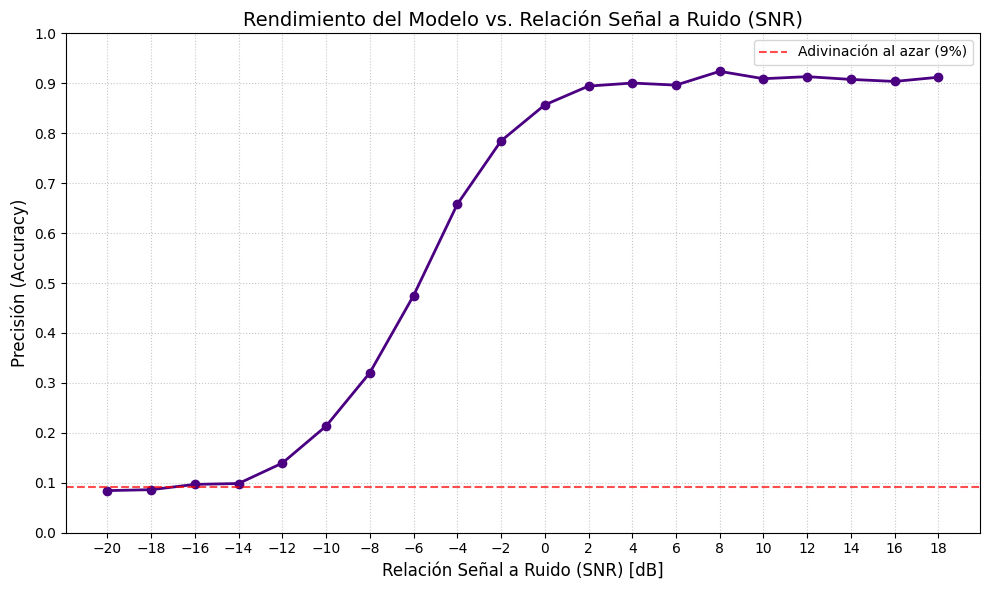

In [ ]:
# Obtener la lista de todos los SNRs únicos ordenados (ej: -20, -18, ..., 18)
snrs_unicos = sorted(np.unique(snrs_test))
acc_por_snr = []

print("Evaluando modelo por nivel de SNR...")

for snr in snrs_unicos:
    # Encontrar los índices de las muestras que tienen este SNR específico
    indices = np.where(snrs_test == snr)[0]
    
    # Filtrar los datos de prueba
    X_test_snr = X_test_norm[indices]
    Y_test_snr = Y_test_num[indices]
    
    # Evaluar el modelo
    loss, acc = model_cnn.evaluate(X_test_snr, Y_test_snr, verbose=0)
    acc_por_snr.append(acc)
    print(f"SNR: {snr:>3} dB | Accuracy: {acc*100:.2f}%")


plt.figure(figsize=(10, 6))
plt.plot(snrs_unicos, acc_por_snr, marker='o', linestyle='-', color='indigo', linewidth=2)

# Línea de referencia (1/11 clases = ~9% de acierto al azar)
plt.axhline(y=1/11, color='red', linestyle='--', alpha=0.7, label='Adivinación al azar (9%)')

plt.title('Rendimiento del Modelo vs. Relación Señal a Ruido (SNR)', fontsize=14)
plt.xlabel('Relación Señal a Ruido (SNR) [dB]', fontsize=12)
plt.ylabel('Precisión (Accuracy)', fontsize=12)
plt.xticks(snrs_unicos)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Prueba de Inferencia

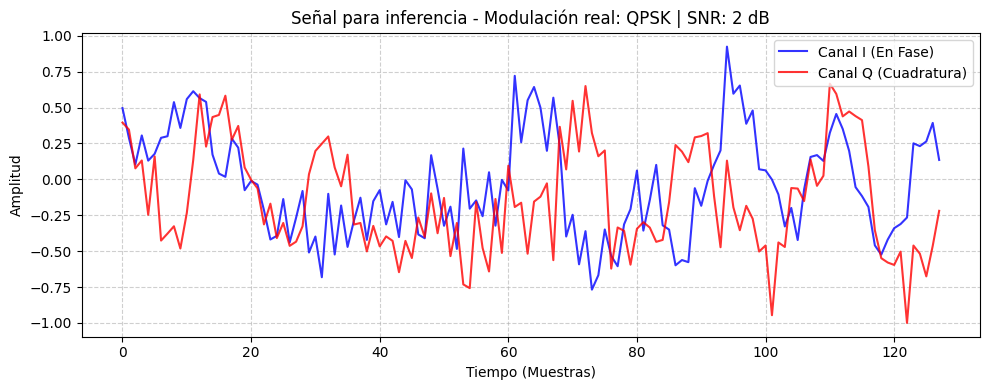

1/1 [==============================] - 0s 18ms/step
Predicción Numérica de la red: 9
Etiqueta Real Numérica:        9
---------------------------------------------
Predicción de la red:          QPSK
Etiqueta Real:                 QPSK

Probabilidades por clase (en %):
Clase 00:   1.66%   (8PSK)
Clase 01:   0.00%   (AM-DSB)
Clase 02:   0.00%   (AM-SSB)
Clase 03:   0.00%   (BPSK)
Clase 04:   0.00%   (CPFSK)
Clase 05:   0.00%   (GFSK)
Clase 06:   0.00%   (PAM4)
Clase 07:   0.09%   (QAM16)
Clase 08:   0.05%   (QAM64)
Clase 09:  98.20%   (QPSK)
Clase 10:   0.00%   (WBFM)

 ¡La red acertó!


In [ ]:
N = 554 # Puedes cambiar este índice

canal_I_norm = X_train_norm[N][0, :] # Canal I (En Fase)
canal_Q_norm = X_train_norm[N][1, :] # Canal Q (Cuadratura)

plt.figure(figsize=(10, 4))
plt.plot(canal_I_norm, label='Canal I (En Fase)', color='blue', alpha=0.8)
plt.plot(canal_Q_norm, label='Canal Q (Cuadratura)', color='red', alpha=0.8)
plt.title(f'Señal para inferencia - Modulación real: {Y_train[N]} | SNR: {snrs[N]} dB')
plt.xlabel('Tiempo (Muestras)')
plt.ylabel('Amplitud')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Agregamos la dimensión del batch: de (2, 128) pasa a (1, 2, 128)
X_single_signal_reshaped = X_train_norm[N].reshape(1, w, h)

y_pred_probs = model_cnn.predict(X_single_signal_reshaped)

# np.argmax nos devuelve el índice de la neurona con la probabilidad más alta
y_pred_label_num = np.argmax(y_pred_probs, axis=1)[0]
y_true_label_num = Y_train_num[N] # Etiqueta numérica real

print("="*45)
print(f"Predicción Numérica de la red: {y_pred_label_num}")
print(f"Etiqueta Real Numérica:        {y_true_label_num}")
print("-"*45)
print(f"Predicción de la red:          {clases[y_pred_label_num]}")
print(f"Etiqueta Real:                 {clases[y_true_label_num]}")
print("="*45)


# Imprimir probabilidades
print("\nProbabilidades por clase (en %):")
probabilidades_porcentaje = np.round(y_pred_probs[0] * 100, 2)
for clase_num, prob in enumerate(probabilidades_porcentaje):
    print(f"Clase {clase_num:02d}: {prob:6.2f}%   ({clases[clase_num]})")

if y_pred_label_num == y_true_label_num:
    print("\n ¡La red acertó!")
else:
    print("\n La red se equivocó.")

## Guardar el Modelo

In [ ]:
import os

# crear carpeta "modelos" dentro del directorio actual
model_save_path = os.path.join(os.getcwd(), "modelos")
os.makedirs(model_save_path, exist_ok=True)

# nombre del archivo
model_name = "modelo_CNN_RadioML.h5"

# ruta completa
full_model_path = os.path.join(model_save_path, model_name)

# guardar el modelo
model_cnn.save(full_model_path)

print("===================================================")
print("Modelo guardado correctamente")
print("Ruta:", full_model_path)
print("===================================================")

Modelo guardado correctamente
Ruta: c:\Users\manue\Posgrado\Cursos\2026\EAMTA\ProyectoFinal\scripts\modelos\modelo_CNN_RadioML.h5


# Cuantización

In [93]:
from tensorflow.keras.models import load_model

# ruta local dentro de la carpeta modelos
model_path = os.path.join(os.getcwd(), "modelos", "modelo_CNN_RadioML.h5")

# cargar modelo
original_model = load_model(model_path)

# mostrar resumen
original_model.summary()

print(f"Modelo cargado desde: {model_path}")

Model: "CNN_1D_RadioML"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_layer (InputLayer)       [(None, 2, 128)]     0           []                               
                                                                                                  
 permutar_dimensiones (Permute)  (None, 128, 2)      0           ['input_layer[0][0]']            
                                                                                                  
 conv_inicial (Conv1D)          (None, 128, 64)      960         ['permutar_dimensiones[0][0]']   
                                                                                                  
 bn_inicial (BatchNormalization  (None, 128, 64)     256         ['conv_inicial[0][0]']           
 )                                                                                   

In [94]:
from qkeras import QDense, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu
from qkeras.utils import model_quantize # Importar model_quantize

## Configuración de la cuantización

### Análisis de distribución de datos y pesos

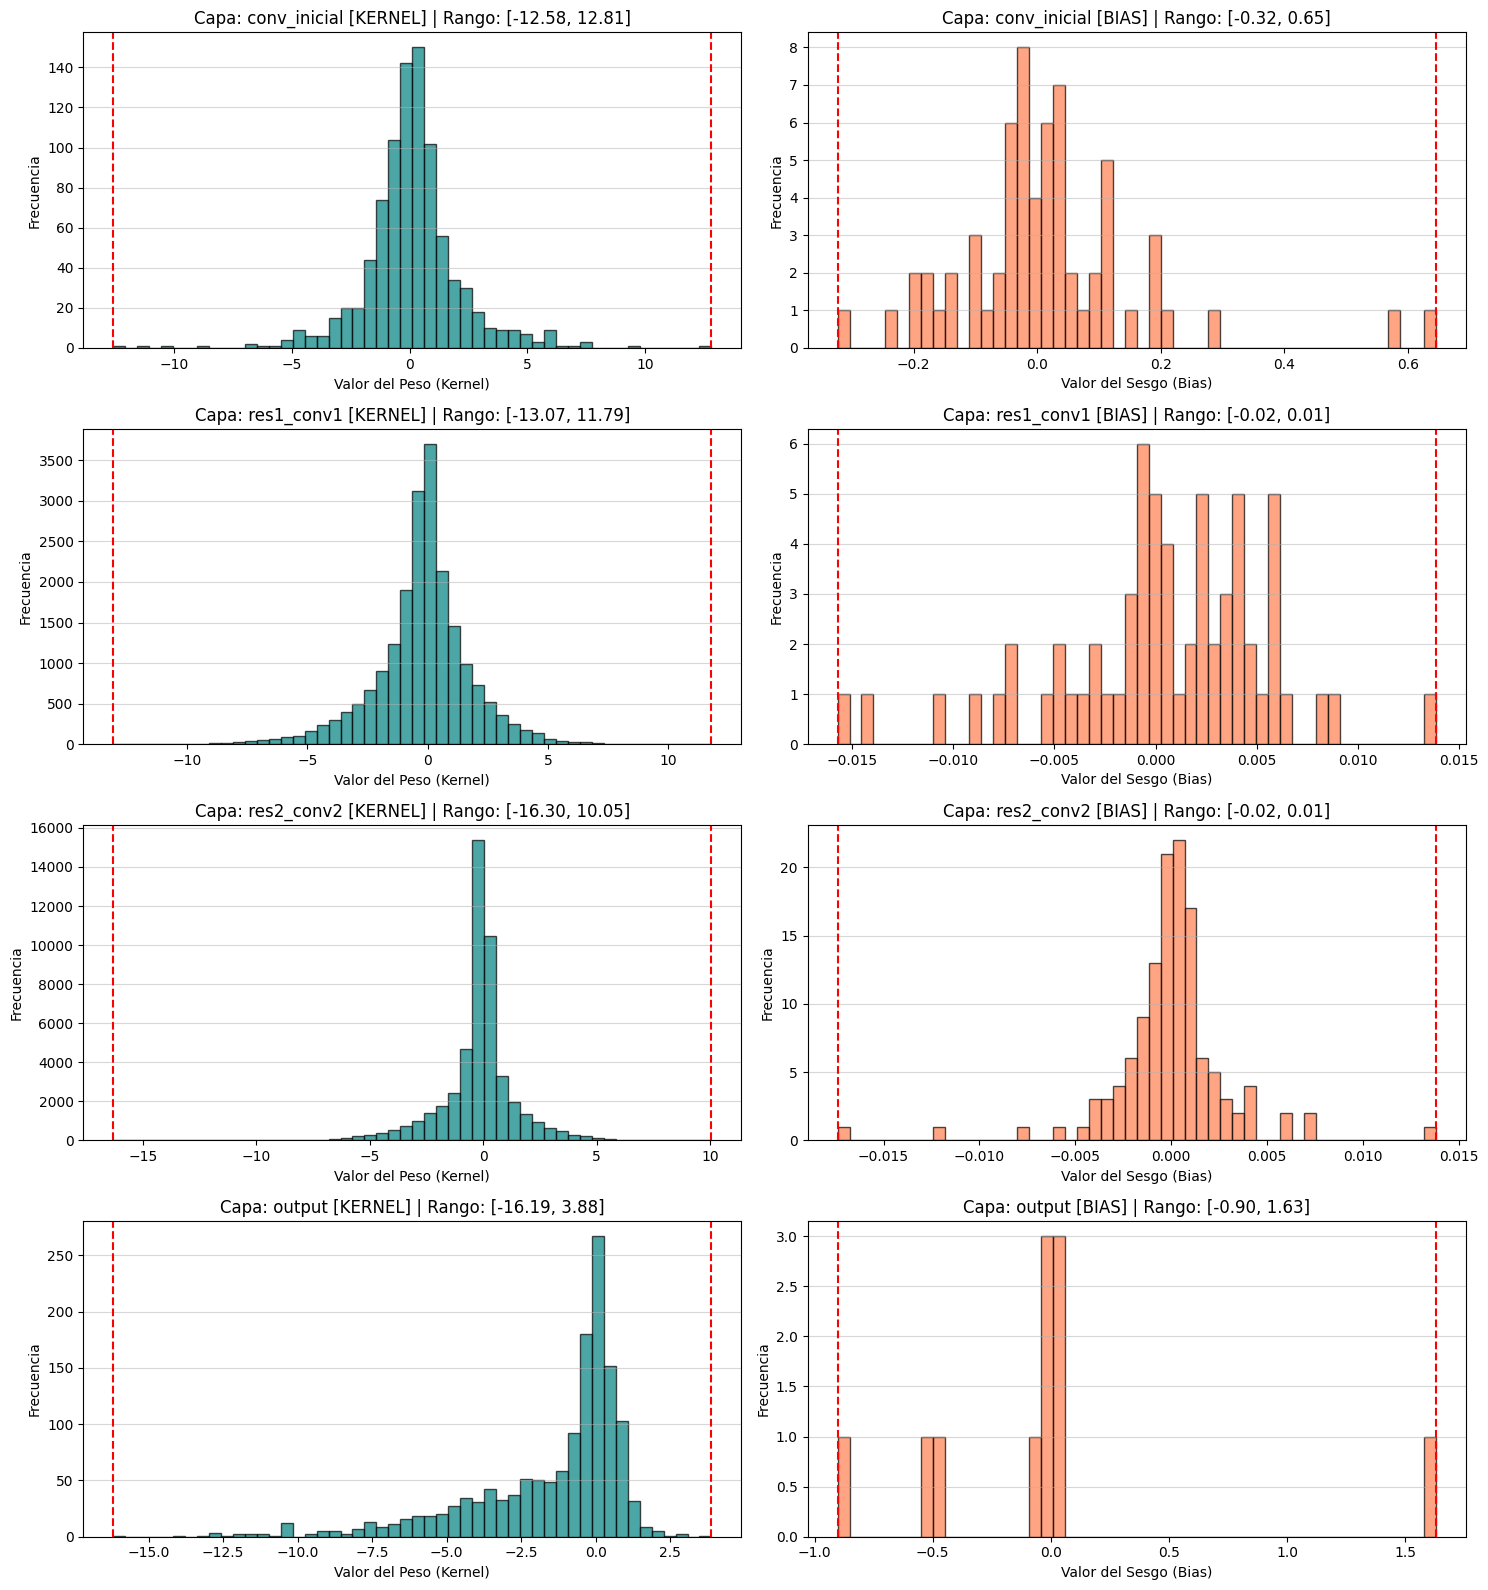

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionamos algunas capas clave de tu ResNet 1D
capas_a_analizar = ['conv_inicial', 'res1_conv1', 'res2_conv2', 'output']

# Agrandamos la figura a 4 filas y 2 columnas
plt.figure(figsize=(15, 16))

for i, nombre_capa in enumerate(capas_a_analizar):
    # Obtenemos la capa del modelo original
    capa = original_model.get_layer(nombre_capa)
    pesos = capa.get_weights()
    
    # Verificamos si la capa tiene pesos (Kernels)
    if len(pesos) > 0:
        # --- 1. GRÁFICO PARA LOS KERNELS ---
        kernel_weights = pesos[0].flatten() 
        
        # Subplot: len(capas_a_analizar) filas, 2 columnas, posición impar (1, 3, 5, 7)
        plt.subplot(len(capas_a_analizar), 2, 2 * i + 1)
        plt.hist(kernel_weights, bins=50, color='teal', alpha=0.7, edgecolor='black')
        
        min_val_k = np.min(kernel_weights)
        max_val_k = np.max(kernel_weights)
        plt.axvline(min_val_k, color='red', linestyle='dashed', linewidth=1.5)
        plt.axvline(max_val_k, color='red', linestyle='dashed', linewidth=1.5)
        
        plt.title(f'Capa: {nombre_capa} [KERNEL] | Rango: [{min_val_k:.2f}, {max_val_k:.2f}]')
        plt.xlabel('Valor del Peso (Kernel)')
        plt.ylabel('Frecuencia')
        plt.grid(axis='y', alpha=0.5)

    # Verificamos si la capa tiene Sesgos (Bias) en el índice 1
    if len(pesos) > 1:
        # --- 2. GRÁFICO PARA LOS BIAS ---
        bias_weights = pesos[1].flatten() 
        
        # Subplot: len(capas_a_analizar) filas, 2 columnas, posición par (2, 4, 6, 8)
        plt.subplot(len(capas_a_analizar), 2, 2 * i + 2)
        plt.hist(bias_weights, bins=50, color='coral', alpha=0.7, edgecolor='black')
        
        min_val_b = np.min(bias_weights)
        max_val_b = np.max(bias_weights)
        plt.axvline(min_val_b, color='red', linestyle='dashed', linewidth=1.5)
        plt.axvline(max_val_b, color='red', linestyle='dashed', linewidth=1.5)
        
        plt.title(f'Capa: {nombre_capa} [BIAS] | Rango: [{min_val_b:.2f}, {max_val_b:.2f}]')
        plt.xlabel('Valor del Sesgo (Bias)')
        plt.ylabel('Frecuencia')
        plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

### Evaluación del modelo

In [ ]:
# Asegurarse de que X_test_norm tenga la forma correcta (batch, height, width, channels)
X_test_norm_reshaped = X_test_norm.reshape(X_test_norm.shape[0], w, h, 1)

# Evaluación del modelo
test_loss_cnn, test_acc_cnn = original_model.evaluate(X_test_norm_reshaped, Y_test_num)
print(f"\nTest accuracy (CNN): {test_acc_cnn:.4f}")

1375/1375 [==============================] - 6s 4ms/step - loss: 1.1152 - accuracy: 0.5972

Test accuracy (CNN): 0.5972


### Elección de la cuantización a utilizar

In [ ]:
from qkeras.utils import model_quantize
from qkeras.quantizers import quantized_bits, quantized_relu
import qkeras

# Diccionario de configuración de cuantización para QKeras
config_quant = {
    # Cuantización para todas las capas convolucionales (Conv1D)
    "QConv1D": {
        "kernel_quantizer": "quantized_bits(8, 4, 1)", 
        "bias_quantizer": "quantized_bits(8, 0, 1)"
    },
    
    # Cuantización para la capa final (Dense)
    "QDense": {
        "kernel_quantizer": "quantized_bits(8, 4, 1)",
        "bias_quantizer": "quantized_bits(8, 1, 1)"
    },
    
    # Cuantización para las funciones de activación
    "QActivation": {
        "relu": "quantized_relu(8, 3)" 
    }
}

In [ ]:
from qkeras import *
from qkeras.utils import model_quantize

# Generamos el modelo cuantizado transfiriendo los pesos
print("Convirtiendo model_cnn a qmodel...")
qmodel = model_quantize(original_model, config_quant, 8, transfer_weights=True) 

# Verificamos cómo quedó configurada cada capa
print("\n--- Verificación de cuantizadores por capa ---")
for layer in qmodel.layers:
    if hasattr(layer, "kernel_quantizer"):
        # Se formatea la salida para que quede alineada y prolija
        print(f"{layer.name:20} kernel: {str(layer.kernel_quantizer_internal):25} bias: {str(layer.bias_quantizer_internal)}")
    elif hasattr(layer, "quantizer"):
        print(f"{layer.name:20} quantizer: {str(layer.quantizer)}")

print("\n--- Resumen del Modelo Cuantizado ---")
qmodel.summary()

Convirtiendo model_cnn a qmodel...

--- Verificación de cuantizadores por capa ---
conv_inicial         kernel: quantized_bits(8,4,1,alpha='auto_po2') bias: quantized_bits(8,0,1)
relu_inicial         quantizer: quantized_relu(8,3)
res1_conv1           kernel: quantized_bits(8,4,1,alpha='auto_po2') bias: quantized_bits(8,0,1)
res1_relu            quantizer: quantized_relu(8,3)
res1_conv2           kernel: quantized_bits(8,4,1,alpha='auto_po2') bias: quantized_bits(8,0,1)
res1_salida          quantizer: quantized_relu(8,3)
res2_conv1           kernel: quantized_bits(8,4,1,alpha='auto_po2') bias: quantized_bits(8,0,1)
res2_relu            quantizer: quantized_relu(8,3)
res2_conv2           kernel: quantized_bits(8,4,1,alpha='auto_po2') bias: quantized_bits(8,0,1)
res2_adaptador       kernel: quantized_bits(8,4,1,alpha='auto_po2') bias: quantized_bits(8,0,1)
res2_salida          quantizer: quantized_relu(8,3)
output               kernel: quantized_bits(8,4,1,alpha='auto_po2') bias: quantiz

## Calibración

In [ ]:
qmodel.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

w = X_train_norm.shape[1]
h = X_train_norm.shape[2]
X_train_norm_reshaped = X_train_norm.reshape(X_train_norm.shape[0], w, h, 1)

history_qmodel = qmodel.fit(
    X_train_norm_reshaped,
    Y_train_num,           
    epochs=1,             
    batch_size=32,        
    validation_split=0.2,  
)

# Evaluación final
test_loss_q, test_acc_q = qmodel.evaluate(X_test_norm_reshaped, Y_test_num)
print(f"\nTest accuracy del modelo cuantizado (8 bits): {test_acc_q:.4f}")

1375/1375 [==============================] - 10s 7ms/step - loss: 1.1206 - accuracy: 0.5930

Test accuracy del modelo cuantizado (8 bits): 0.5930


### Evaluación del Modelo Cuantizado vs Modelo en punto flotante

Analizando 2181 señales con SNR = 8 dB...

Accuracy original (Punto Flotante) : 92.39%
Accuracy cuantizado (8 bits QAT)   : 91.61%
Diferencia de Accuracy             : 0.78%



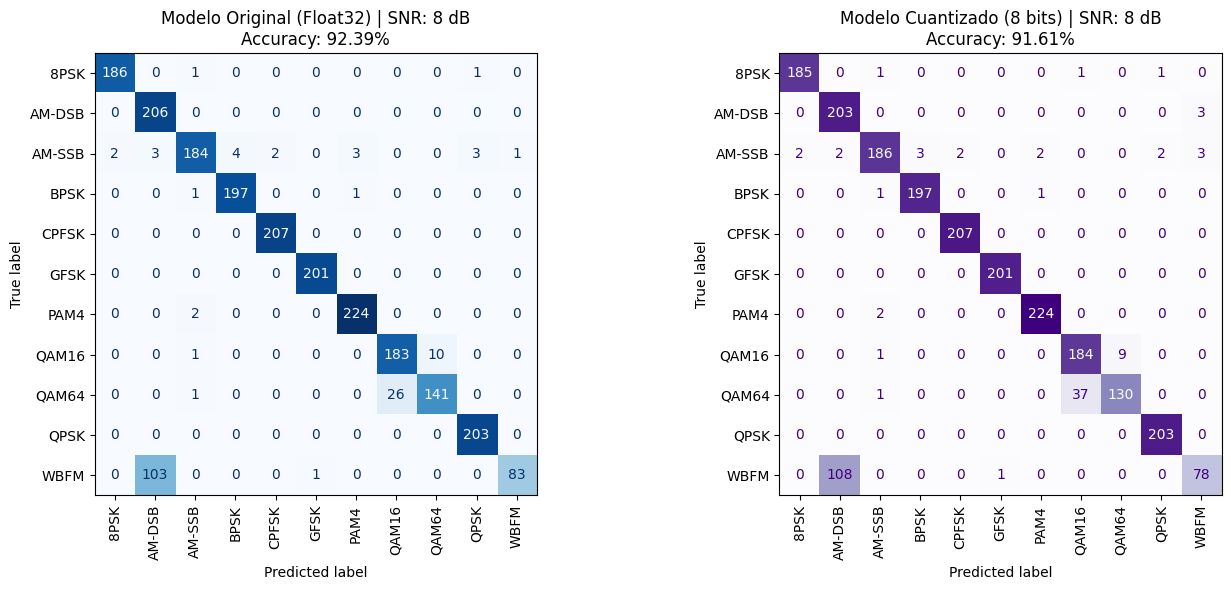

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ===========================================================================
# 0) SELECCIÓN DE SNR Y FILTRADO DE DATOS
# ===========================================================================
snr_seleccionado = 8

# Buscamos los índices de las señales que corresponden a este SNR
indices_snr = np.where(snrs_test == snr_seleccionado)[0]

# Verificamos que existan datos para ese SNR
if len(indices_snr) == 0:
    print(f"No se encontraron señales con SNR = {snr_seleccionado} dB en el conjunto de prueba.")
else:
    print(f"Analizando {len(indices_snr)} señales con SNR = {snr_seleccionado} dB...\n")

    # Extraemos solo las señales y etiquetas de ese SNR
    X_test_filtrado = X_test_norm_reshaped[indices_snr]
    Y_test_filtrado = Y_test_num[indices_snr]

    # ===========================================================================
    # 1) PREDICCIÓN (Solo sobre los datos filtrados)
    # ===========================================================================
    y_pred_q = qmodel.predict(X_test_filtrado, verbose=0)
    y_pred_f = original_model.predict(X_test_filtrado, verbose=0)

    # ===========================================================================
    # 2) CONVERTIR A ETIQUETAS
    # ===========================================================================
    y_pred_q_lbl = np.argmax(y_pred_q, axis=1)
    y_pred_f_lbl = np.argmax(y_pred_f, axis=1)

    # ===========================================================================
    # 3) MÉTRICAS NUMÉRICAS BÁSICAS
    # ===========================================================================
    acc_q = accuracy_score(Y_test_filtrado, y_pred_q_lbl)
    acc_f = accuracy_score(Y_test_filtrado, y_pred_f_lbl)

    print(f"Accuracy original (Punto Flotante) : {acc_f * 100:.2f}%")
    print(f"Accuracy cuantizado (8 bits QAT)   : {acc_q * 100:.2f}%")
    print(f"Diferencia de Accuracy             : {(acc_f - acc_q) * 100:.2f}%\n")


    # ===========================================================================
    # 4) MATRICES DE CONFUSIÓN COMPARATIVAS
    # ===========================================================================
    cm_q = confusion_matrix(Y_test_filtrado, y_pred_q_lbl)
    cm_f = confusion_matrix(Y_test_filtrado, y_pred_f_lbl)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Gráfico del Modelo Original
    disp_f = ConfusionMatrixDisplay(confusion_matrix=cm_f, display_labels=clases)
    disp_f.plot(ax=axes[0], cmap="Blues", xticks_rotation='vertical', colorbar=False)
    axes[0].set_title(f"Modelo Original (Float32) | SNR: {snr_seleccionado} dB\nAccuracy: {acc_f*100:.2f}%")
    
    # Gráfico del Modelo Cuantizado
    disp_q = ConfusionMatrixDisplay(confusion_matrix=cm_q, display_labels=clases)
    disp_q.plot(ax=axes[1], cmap="Purples", xticks_rotation='vertical', colorbar=False)
    axes[1].set_title(f"Modelo Cuantizado (8 bits) | SNR: {snr_seleccionado} dB\nAccuracy: {acc_q*100:.2f}%")

    plt.tight_layout()
    plt.show()

### Gráfico en función de la SNR

Evaluando modelos comparativamente por nivel de SNR...
-----------------------------------------------------------------
SNR (dB)   | Acc Original (Float32)    | Acc Cuantizado (8 bits)  
-----------------------------------------------------------------
  -20 dB   |                 8.43%    |                 8.48%
  -18 dB   |                 8.62%    |                 8.48%
  -16 dB   |                 9.68%    |                 9.37%
  -14 dB   |                 9.86%    |                 9.36%
  -12 dB   |                13.94%    |                12.72%
  -10 dB   |                21.35%    |                19.60%
   -8 dB   |                32.02%    |                30.76%
   -6 dB   |                47.47%    |                47.70%
   -4 dB   |                65.77%    |                64.68%
   -2 dB   |                78.46%    |                78.09%
    0 dB   |                85.67%    |                84.74%
    2 dB   |                89.44%    |                89.48%
  

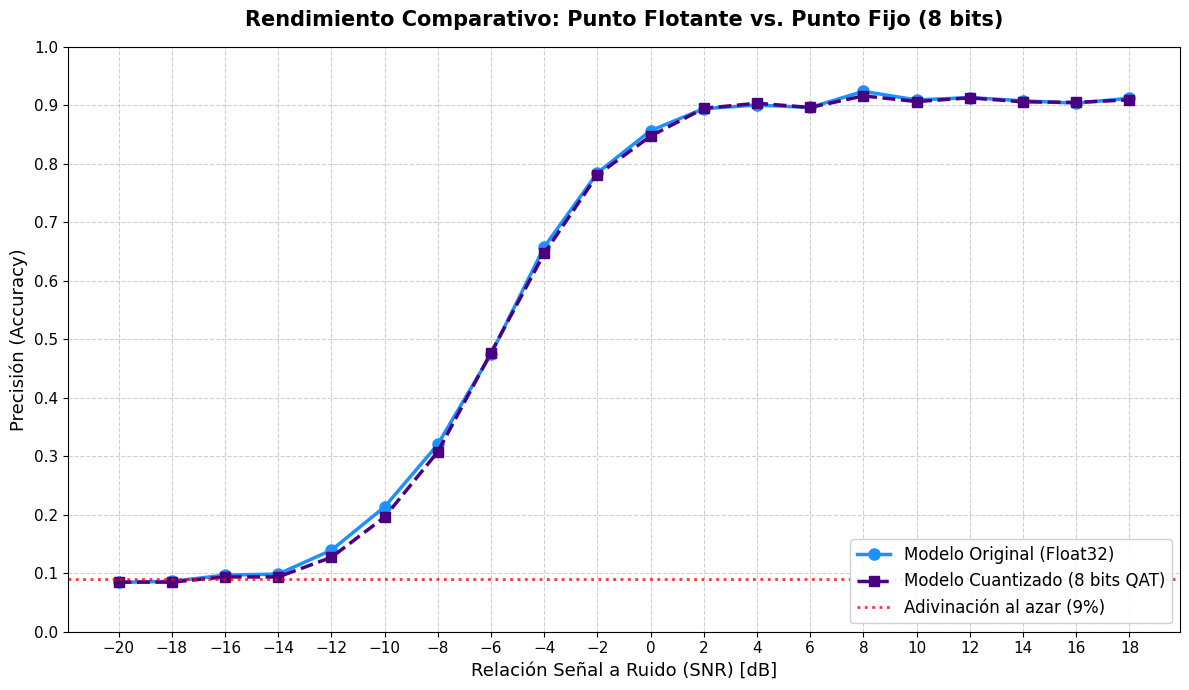

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Obtener la lista de todos los SNRs únicos ordenados
snrs_unicos = sorted(np.unique(snrs_test))

# Listas para guardar los resultados de ambos modelos
acc_por_snr_f = [] # Para el modelo original (Float32)
acc_por_snr_q = [] # Para el modelo cuantizado (8 bits)

print("Evaluando modelos comparativamente por nivel de SNR...")
print("-" * 65)
print(f"{'SNR (dB)':<10} | {'Acc Original (Float32)':<25} | {'Acc Cuantizado (8 bits)':<25}")
print("-" * 65)

for snr in snrs_unicos:
    # Encontrar los índices de las muestras que tienen este SNR específico
    indices = np.where(snrs_test == snr)[0]
    
    # Filtrar los datos de prueba (usamos reshaped para que encaje en Conv1D)
    X_test_snr = X_test_norm_reshaped[indices]
    Y_test_snr = Y_test_num[indices]
    
    # Evaluar el modelo original en punto flotante
    _, acc_f = original_model.evaluate(X_test_snr, Y_test_snr, verbose=0)
    acc_por_snr_f.append(acc_f)
    
    # Evaluar el modelo cuantizado
    _, acc_q = qmodel.evaluate(X_test_snr, Y_test_snr, verbose=0)
    acc_por_snr_q.append(acc_q)
    
    print(f"{snr:>5} dB   | {acc_f*100:>20.2f}%    | {acc_q*100:>20.2f}%")

print("-" * 65)


plt.figure(figsize=(12, 7))

# Línea del modelo original (Sólida con círculos)
plt.plot(snrs_unicos, acc_por_snr_f, marker='o', linestyle='-', color='dodgerblue', 
         linewidth=2.5, markersize=8, label='Modelo Original (Float32)')

# Línea del modelo cuantizado (Punteada con cuadrados, color oscuro para contrastar)
plt.plot(snrs_unicos, acc_por_snr_q, marker='s', linestyle='--', color='indigo', 
         linewidth=2.5, markersize=7, label='Modelo Cuantizado (8 bits QAT)')

# Línea de referencia (1/11 clases = ~9% de acierto al azar)
plt.axhline(y=1/11, color='red', linestyle=':', alpha=0.8, linewidth=2, label='Adivinación al azar (9%)')

# Configuraciones estéticas del gráfico
plt.title('Rendimiento Comparativo: Punto Flotante vs. Punto Fijo (8 bits)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Relación Señal a Ruido (SNR) [dB]', fontsize=13)
plt.ylabel('Precisión (Accuracy)', fontsize=13)
plt.xticks(snrs_unicos, fontsize=11)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Leyenda bien ubicada
plt.legend(loc='lower right', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.show()

### Guardar el modelo cuantizado

In [102]:
model_save_path = os.path.join(os.getcwd(), "modelos")
os.makedirs(model_save_path, exist_ok=True)

# nombre del archivo
model_name = "modelo_CNN_RadioML_QAT.h5"

# ruta completa
full_model_path = os.path.join(model_save_path, model_name)

# guardar el modelo correcto (qmodel)
qmodel.save(full_model_path)

print("===================================================")
print("Modelo guardado correctamente")
print("Ruta:", full_model_path)
print("===================================================")

Modelo guardado correctamente
Ruta: c:\Users\manue\Posgrado\Cursos\2026\EAMTA\ProyectoFinal\scripts\modelos\modelo_CNN_RadioML_QAT.h5


# Análisis para implementación en Hardware

## Cargar el modelo cuantizado

In [103]:
from tensorflow.keras.models import load_model
from qkeras.utils import _add_supported_quantized_objects
from qkeras import *

## Cargo el modelo cuantizado
model_path = os.path.join(os.getcwd(), "modelos")
model_name = "modelo_CNN_RadioML_QAT.h5"

full_path = os.path.join(model_path, model_name)

co = {}
_add_supported_quantized_objects(co)

qmodel = load_model(full_path, custom_objects=co)

qmodel.summary()

Model: "CNN_1D_RadioML"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_layer (InputLayer)       [(None, 2, 128)]     0           []                               
                                                                                                  
 permutar_dimensiones (Permute)  (None, 128, 2)      0           ['input_layer[0][0]']            
                                                                                                  
 conv_inicial (QConv1D)         (None, 128, 64)      960         ['permutar_dimensiones[0][0]']   
                                                                                                  
 bn_inicial (BatchNormalization  (None, 128, 64)     256         ['conv_inicial[0][0]']           
 )                                                                                   

## Verificar pesos del modelo cuantizado

In [104]:
def weight_stats(model):

    for layer in model.layers:
        weights = layer.get_weights()

        if len(weights) > 0:
            w = weights[0]

            print(layer.name)
            print("shape:", w.shape)
            print("min:", np.min(w))
            print("max:", np.max(w))
            print("std:", np.std(w))
            print()

In [105]:
weight_stats(qmodel)

conv_inicial
shape: (7, 2, 64)
min: -12.618674
max: 12.783798
std: 2.0934033

bn_inicial
shape: (64,)
min: -0.04801726
max: 2.6113381
std: 0.6886487

res1_conv1
shape: (5, 64, 64)
min: -13.166207
max: 11.814742
std: 1.9894899

res1_bn1
shape: (64,)
min: 0.13221489
max: 4.521474
std: 0.9943611

res1_conv2
shape: (5, 64, 64)
min: -11.978906
max: 8.425614
std: 2.001091

res1_bn2
shape: (64,)
min: -0.4763265
max: 1.7392949
std: 0.57146895

res2_conv1
shape: (3, 64, 128)
min: -15.369834
max: 14.510374
std: 1.6492201

res2_bn1
shape: (128,)
min: -0.13664377
max: 6.6648426
std: 1.5912375

res2_conv2
shape: (3, 128, 128)
min: -15.996698
max: 10.040193
std: 1.606365

res2_bn2
shape: (128,)
min: 0.04661158
max: 3.7644663
std: 0.9996056

res2_adaptador
shape: (1, 64, 128)
min: -9.35121
max: 4.4894114
std: 1.1740098

output
shape: (128, 11)
min: -15.944672
max: 3.7699878
std: 2.6402156



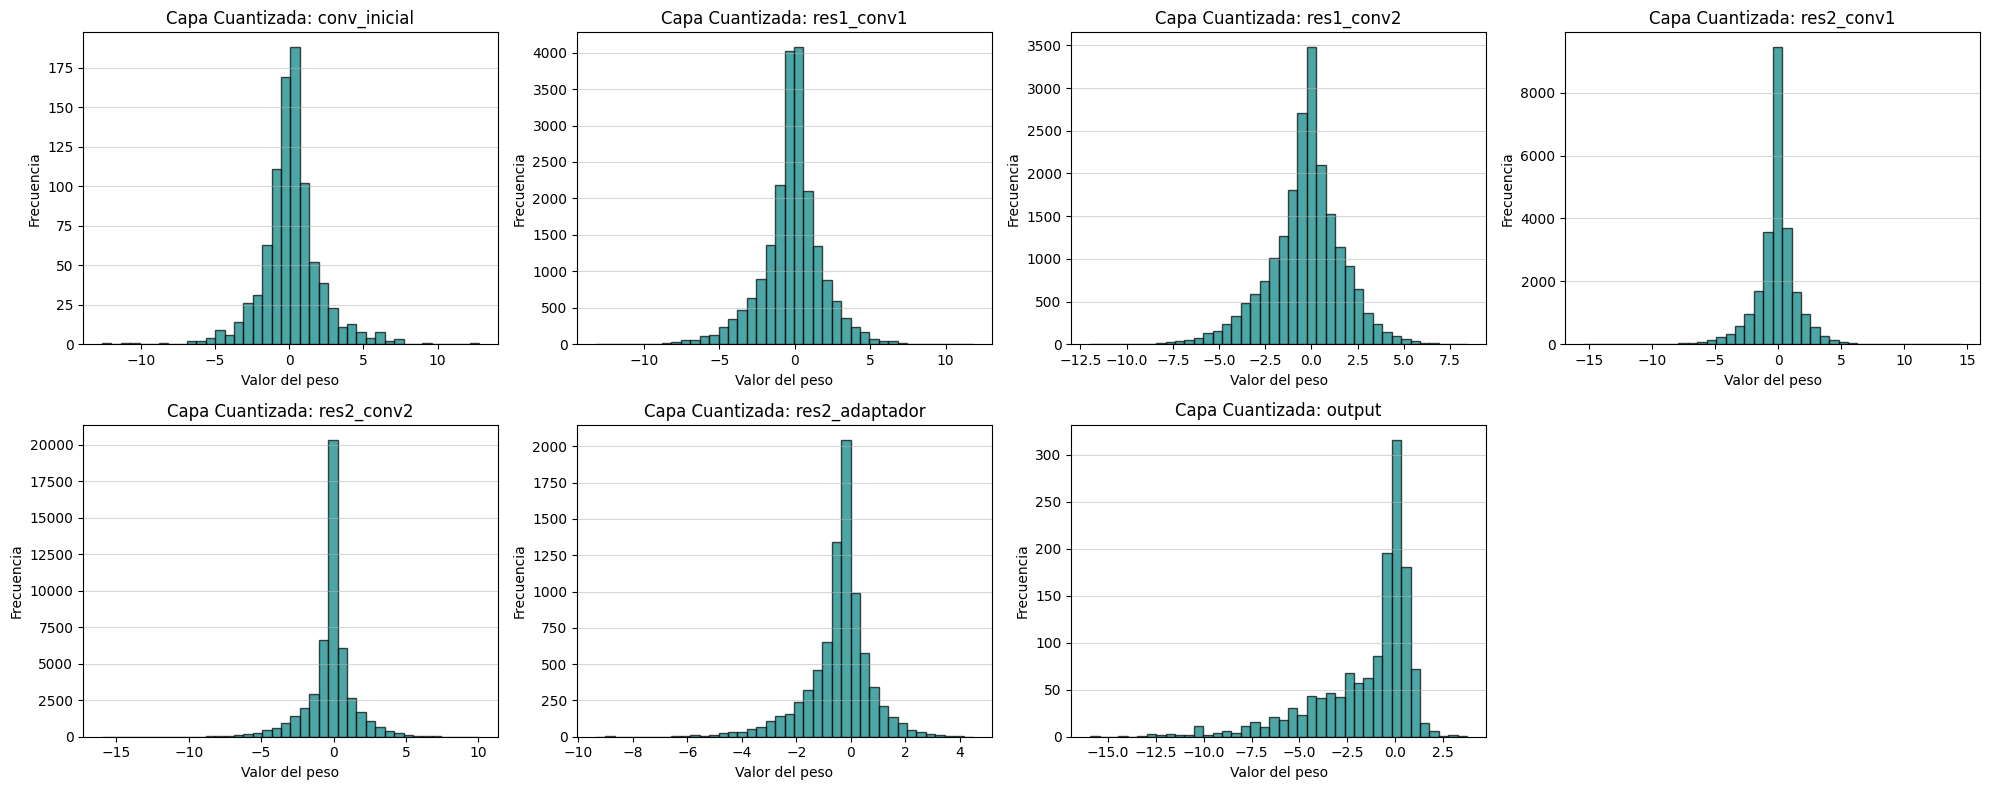

In [106]:
# Obtener capas con pesos (Qmodel)
layers = [layer for layer in qmodel.layers if hasattr(layer, "kernel")]
n_layers = len(layers)

# Definimos 2 filas y calculamos las columnas (redondeando hacia arriba por si es impar)
n_rows = 2
n_cols = (n_layers + 1) // 2 

# Ajustamos el tamaño de la figura en función de las filas y columnas
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

# Aplanamos la matriz de gráficos para poder iterar con un solo bucle 'for'
axes = axes.flatten()

for i, layer in enumerate(layers):
    weights = layer.get_weights()[0]   # extraemos el kernel
    w = weights.flatten()

    # Graficamos en el subgráfico correspondiente al índice 'i'
    axes[i].hist(w, bins=40, color='teal', alpha=0.7, edgecolor='black')
    axes[i].set_title(f"Capa Cuantizada: {layer.name}")
    axes[i].set_xlabel("Valor del peso")
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(axis='y', alpha=0.5)

# Si el número de capas es impar, nos sobrará un gráfico en blanco al final.
# Este bucle apaga (oculta) los subgráficos sobrantes para que se vea prolijo.
for j in range(n_layers, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Estadísticas generales sobre operaciones

In [107]:
# Esta función me da una estadisticas capa por capa de la cantidad de operaciones.
# Puede elejir el modelo que usted quiera o realizar diferentes compraciones
print_qstats(qmodel)


Number of operations in model:
    conv_inicial                  : 114688 (smult_8_8)
    output                        : 1408  (smult_8_8)
    res1_conv1                    : 2621440 (smult_8_8)
    res1_conv2                    : 2621440 (smult_8_8)
    res2_adaptador                : 524288 (smult_8_8)
    res2_conv1                    : 1572864 (smult_8_8)
    res2_conv2                    : 3145728 (smult_8_8)

Number of operation types in model:
    smult_8_8                     : 10601856

Weight profiling:
    conv_inicial_weights           : 896   (8-bit unit)
    conv_inicial_bias              : 64    (8-bit unit)
    output_weights                 : 1408  (8-bit unit)
    output_bias                    : 11    (8-bit unit)
    res1_conv1_weights             : 20480 (8-bit unit)
    res1_conv1_bias                : 64    (8-bit unit)
    res1_conv2_weights             : 20480 (8-bit unit)
    res1_conv2_bias                : 64    (8-bit unit)
    res2_adaptador_weights     

In [108]:
#ESTA FUNCIÓN SE UTILIZA PARA VER LOS PESOS GUARDADOS DEL MODELO.
print(qmodel.weights)

[<tf.Variable 'conv_inicial/kernel:0' shape=(7, 2, 64) dtype=float32, numpy=
array([[[-4.6250000e+00,  6.8750000e-01, -1.6250000e+00, -7.8125000e-01,
          9.3750000e-02,  8.7500000e-01,  1.5312500e+00,  6.2500000e-02,
          8.8281250e-01,  4.6875000e-02, -3.2187500e+00,  4.3750000e+00,
          5.9375000e+00,  8.7500000e-01, -1.7812500e+00,  1.2187500e+00,
         -1.7500000e+00,  3.9687500e+00,  1.2750000e+01, -7.9375000e+00,
          7.0312500e-01,  2.5937500e+00, -3.6875000e+00, -3.2500000e+00,
         -3.3125000e+00,  3.1250000e+00,  3.9375000e+00,  1.9375000e+00,
         -4.9609375e-01, -3.0000000e+00, -2.0625000e+00, -1.4062500e+00,
          3.2500000e+00,  9.9218750e-01,  1.7500000e+00, -8.7500000e-01,
          2.8125000e-01, -3.1250000e-01, -5.9375000e-01,  5.7812500e-01,
         -4.9375000e+00, -8.7500000e-01, -1.9062500e+00,  5.6250000e+00,
         -3.9687500e+00, -1.2500000e-01, -1.5000000e+00,  5.7812500e-01,
         -9.6875000e-01,  3.1250000e-02, -5.937

## Cálculo de energía

Cada operación (MAC, suma, acceso a memoria) tiene un costo energético tabulado según el ancho de bits. Esto es lo que transforma “cantidad de operaciones” en “energía”.

# En este ejemplo de utiliza para el cálculo de energía el proceso de Horowitz
    "horowitz" refers to 45nm process published at:
    M. Horowitz, "1.1 Computing's energy problem (and what we can do about  it), "2014 IEEE International Solid-State Circuits Conference Digest of Technical Papers (ISSCC), San Francisco, CA, 2014, pp. 10-14,
    doi: 10.1109/ISSCC.2014.6757323.

### Definiciones necesarias para el cálculo de energía

In [ ]:
# ===========================================================================
# 1) CONFIGURACIÓN DE REFERENCIAS INTERNAS
# ===========================================================================
# Para capas puras de Keras (ej. MaxPooling1D, Add, Flatten) que no tienen 
# cuantización explícita, asumimos buses de datos de 8 bits.
reference_internal = "int8"

reference_accumulator = "int32"

# ===========================================================================
# 2) INSTANCIACIÓN DE QTOOLS
# ===========================================================================
print("Analizando arquitectura y estimando consumo energético...")

q = run_qtools.QTools(
    qmodel, 
    process="horowitz", # Utiliza el modelo de energía de Horowitz (estándar académico)
    
    # Simula físicamente nuestro ADC (Conversor Analógico-Digital). 
    # Como nuestras señales de entrada I/Q están normalizadas entre [-1, 1], 
    # el ADC muestreará en 8 bits puros fraccionarios.
    source_quantizers=[quantizers.quantized_bits(8, 0, 1)], 
    
    is_inference=True,      # Estimamos el consumo del Forward Pass (Clasificación)
    weights_path=None,      # Lee los pesos directamente del modelo en RAM
    keras_quantizer=reference_internal, 
    keras_accumulator=reference_accumulator,
    for_reference=False     # Respeta estrictamente los cuantizadores que diseñaste antes
)

# ===========================================================================
# 3) ESTIMACIÓN BASADA EN ARQUITECTURA DE MEMORIA
# ===========================================================================
trial_energy_dict = q.pe(
    weights_on_memory="sram",
    activations_on_memory="sram",  # Todo en SRAM interna, sin ir a DRAM externa
    min_sram_size=1 * 1024 * 1024, # Límite de 1MB de SRAM (nuestra CNN 1D entra perfecto)
    rd_wr_on_io=True               # Considera el gasto energético de mover datos a los pines E/S
)

# ===========================================================================
# 4) EXTRACCIÓN DE RESULTADOS
# ===========================================================================
trial_energy_profile = q.extract_energy_profile(
    qtools_settings.cfg.include_energy, trial_energy_dict
)

total_trial_energy = q.extract_energy_sum(
    qtools_settings.cfg.include_energy, trial_energy_dict
)

# QTools devuelve la energía en picoJulios (pJ) por inferencia
print(f"\n✅ Energía total estimada por inferencia: {total_trial_energy:.2f} pJ")

# Imprimimos también el consumo en microJulios (uJ) para mejor legibilidad si el número es grande
print(f"   (Equivalente a {total_trial_energy / 1e6:.6f} µJ)")

CRITICAL:absl:unsupported kernel shape, it is neither a dense kernel of length 2, nor a convolution kernel of length 4
CRITICAL:absl:unsupported kernel shape, it is neither a dense kernel of length 2, nor a convolution kernel of length 4
CRITICAL:absl:unsupported kernel shape, it is neither a dense kernel of length 2, nor a convolution kernel of length 4
CRITICAL:absl:unsupported kernel shape, it is neither a dense kernel of length 2, nor a convolution kernel of length 4
CRITICAL:absl:unsupported kernel shape, it is neither a dense kernel of length 2, nor a convolution kernel of length 4
CRITICAL:absl:unsupported kernel shape, it is neither a dense kernel of length 2, nor a convolution kernel of length 4


Analizando arquitectura y estimando consumo energético...
operation count for <keras.layers.reshaping.permute.Permute object at 0x00000142DF1040D0> is defaulted to 0
operation count for <keras.layers.pooling.global_average_pooling1d.GlobalAveragePooling1D object at 0x00000142DF2E1890> is defaulted to 0

✅ Energía total estimada por inferencia: 2999833.00 pJ
   (Equivalente a 2.999833 µJ)


### Impresión de los valores de energía asociada al modelo

In [110]:
print("energy profile:", trial_energy_profile)
print("Total energy:", total_trial_energy)
print_qstats(qmodel)

energy profile: {'permutar_dimensiones': {'energy': {'inputs': 41620.59, 'outputs': 20.59, 'parameters': 0.0, 'op_cost': 0.0}, 'total': 41620.59}, 'conv_inicial': {'energy': {'inputs': 20.59, 'outputs': 1647.41, 'parameters': 77.22, 'op_cost': 30105.6}, 'total': 30203.41}, 'bn_inicial': {'energy': {'inputs': 1647.41, 'outputs': 2635.86, 'parameters': 20.59, 'op_cost': 50790.4}, 'total': 20.59}, 'relu_inicial': {'energy': {'inputs': 2635.86, 'outputs': 658.96, 'parameters': 0.0, 'op_cost': 0.0}, 'total': 658.96}, 'res1_conv1': {'energy': {'inputs': 658.96, 'outputs': 2059.27, 'parameters': 1652.56, 'op_cost': 729088.0}, 'total': 731399.52}, 'res1_bn1': {'energy': {'inputs': 2059.27, 'outputs': 2635.86, 'parameters': 20.59, 'op_cost': 50790.4}, 'total': 20.59}, 'res1_relu': {'energy': {'inputs': 2635.86, 'outputs': 658.96, 'parameters': 0.0, 'op_cost': 0.0}, 'total': 658.96}, 'res1_conv2': {'energy': {'inputs': 658.96, 'outputs': 2059.27, 'parameters': 1652.56, 'op_cost': 729088.0}, 'tot

In [ ]:
# ===========================================================================
# MÉTRICAS DE DESEMPEÑO DEL MODELO CUANTIZADO (8 BITS)
# ===========================================================================

# Precisión
Precision = 0.5930 # Reemplazar por test_acc_q si lo tienes en memoria

# MACs: Extraído de "Number of operations in model"
MACs = 114688 + 1408 + 2621440 + 2621440 + 524288 + 1572864 + 3145728

# Sparsity: Extraído de "Total Sparsity"
sparsity = 0.0277

# Memoria: Suma de todos los pesos y bias listados en "Weight profiling"
# La suma total en bits es:
Memoria_bits = (
    896 * 8 + 64 * 8 +       # conv_inicial
    1408 * 8 + 11 * 8 +      # output
    20480 * 8 + 64 * 8 +     # res1_conv1
    20480 * 8 + 64 * 8 +     # res1_conv2
    8192 * 8 + 128 * 8 +     # res2_adaptador
    24576 * 8 + 128 * 8 +    # res2_conv1
    49152 * 8 + 128 * 8      # res2_conv2
)

# 5. Energía: Extraído de "Total energy"
Energia_pJ = 2999833.00

# 6. Medida de Desempeño (FoM): Precisión por unidad de Energía
med = Precision / Energia_pJ

# --- IMPRESIÓN DE RESULTADOS ---
print("-" * 40)
print("RESUMEN DE HARDWARE Y DESEMPEÑO")
print("-" * 40)
print(f"Precisión (Accuracy) : {Precision:.4f}")
print(f"Total MACs           : {MACs:,} operaciones")
print(f"Sparsity             : {sparsity:.4f} ({(sparsity*100):.2f}% ceros)")
print(f"Memoria (Bits)       : {Memoria_bits:,} Bits")
print(f"Energía Total        : {Energia_pJ:,} pJ")
print(f"Medida de Desempeño  : {med:.4e} (Acc / pJ)")
print("-" * 40)

----------------------------------------
RESUMEN DE HARDWARE Y DESEMPEÑO
----------------------------------------
Precisión (Accuracy) : 0.5930
Total MACs           : 10,601,856 operaciones
Sparsity             : 0.0277 (2.77% ceros)
Memoria (Bits)       : 1,006,168 Bits
Energía Total        : 2,999,833.0 pJ
Medida de Desempeño  : 1.9768e-07 (Acc / pJ)
----------------------------------------


# Resultados esperados

Preparando modelos para la comparativa SNR...

Iniciando QAT (Fine-Tuning) para el modelo de 4 bits...
4400/4400 [==============================] - 110s 24ms/step - loss: 1.3578 - accuracy: 0.5153 - val_loss: 1.1712 - val_accuracy: 0.5711
Entrenamiento de 4 bits finalizado.

-------------------------------------------------------
SNR (dB)   | 32-bit (%)   | 8-bit (%)    | 4-bit (%)   
-------------------------------------------------------
  -20 dB   |       8.43% |       8.48% |       8.95%
  -18 dB   |       8.62% |       8.48% |       8.98%
  -16 dB   |       9.68% |       9.37% |      10.30%
  -14 dB   |       9.86% |       9.36% |       9.68%
  -12 dB   |      13.94% |      12.72% |      13.26%
  -10 dB   |      21.35% |      19.60% |      19.69%
   -8 dB   |      32.02% |      30.76% |      28.57%
   -6 dB   |      47.47% |      47.70% |      42.88%
   -4 dB   |      65.77% |      64.68% |      61.04%
   -2 dB   |      78.46% |      78.09% |      73.91%
    0 dB   |      85.67% |

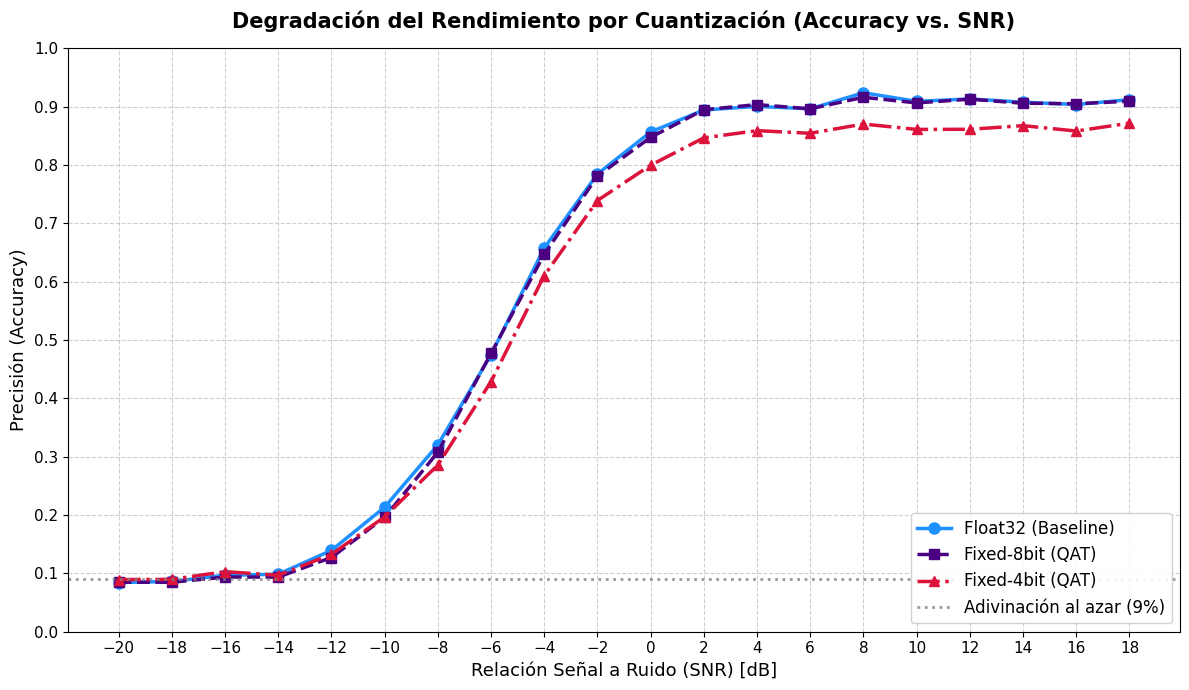

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from qkeras.utils import model_quantize

print("Preparando modelos para la comparativa SNR...")

# Construimos el modelo de 4 bits
conf_4bit = {
    "QConv1D": {"kernel_quantizer": "quantized_bits(4, 2, 1)", 
                "bias_quantizer": "quantized_bits(4, 0, 1)"},
    "QDense": {"kernel_quantizer": "quantized_bits(4, 2, 1)", 
               "bias_quantizer": "quantized_bits(4, 0, 1)"},
    "QActivation": {"relu": "quantized_relu(4, 2)"}
}
qmodel_4b = model_quantize(original_model, conf_4bit, 4, transfer_weights=True)

# Compilamos
qmodel_4b.compile(
    optimizer=Adam(learning_rate=1e-4), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# =========================================================================
# Fine-Tuning (QAT) para el modelo de 4 bits
# =========================================================================
print("\nIniciando QAT (Fine-Tuning) para el modelo de 4 bits...")
qmodel_4b.fit(
    X_train_norm_reshaped,
    Y_train_num,
    epochs=1,            # Le damos 10 épocas para que intente recuperarse
    batch_size=32,
    validation_split=0.2,
    verbose=1             # Ponlo en 0 si no quieres que llene la pantalla
)
print("Entrenamiento de 4 bits finalizado.\n")

# Obtener SNRs únicos
snrs_unicos = sorted(np.unique(snrs_test))

# Listas para guardar resultados
acc_32b = []
acc_8b = []
acc_4b = []

print("-" * 55)
print(f"{'SNR (dB)':<10} | {'32-bit (%)':<12} | {'8-bit (%)':<12} | {'4-bit (%)':<12}")
print("-" * 55)

for snr in snrs_unicos:
    # Filtrar datos por SNR
    indices = np.where(snrs_test == snr)[0]
    X_test_snr = X_test_norm_reshaped[indices]
    Y_test_snr = Y_test_num[indices]
    
    # Evaluar los 3 modelos
    _, a_32 = original_model.evaluate(X_test_snr, Y_test_snr, verbose=0)
    _, a_8  = qmodel.evaluate(X_test_snr, Y_test_snr, verbose=0)
    _, a_4  = qmodel_4b.evaluate(X_test_snr, Y_test_snr, verbose=0)
    
    acc_32b.append(a_32)
    acc_8b.append(a_8)
    acc_4b.append(a_4)
    
    print(f"{snr:>5} dB   | {a_32*100:>10.2f}% | {a_8*100:>10.2f}% | {a_4*100:>10.2f}%")

print("-" * 55)


plt.figure(figsize=(12, 7))

# Curva 32 bits (Original)
plt.plot(snrs_unicos, acc_32b, marker='o', linestyle='-', color='dodgerblue', 
         linewidth=2.5, markersize=8, label='Float32 (Baseline)')

# Curva 8 bits
plt.plot(snrs_unicos, acc_8b, marker='s', linestyle='--', color='indigo', 
         linewidth=2.5, markersize=7, label='Fixed-8bit (QAT)')

# Curva 4 bits
plt.plot(snrs_unicos, acc_4b, marker='^', linestyle='-.', color='crimson', 
         linewidth=2.5, markersize=7, label='Fixed-4bit (QAT)')

# Línea de referencia (azar)
plt.axhline(y=1/11, color='gray', linestyle=':', alpha=0.8, linewidth=2, label='Adivinación al azar (9%)')

plt.title('Degradación del Rendimiento por Cuantización (Accuracy vs. SNR)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Relación Señal a Ruido (SNR) [dB]', fontsize=13)
plt.ylabel('Precisión (Accuracy)', fontsize=13)
plt.xticks(snrs_unicos, fontsize=11)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=12, framealpha=0.9)
plt.tight_layout()
plt.show()

### Matrices de confusión

Filtrando datos para SNR = 18 dB...
Generando predicciones sobre 2128 muestras...


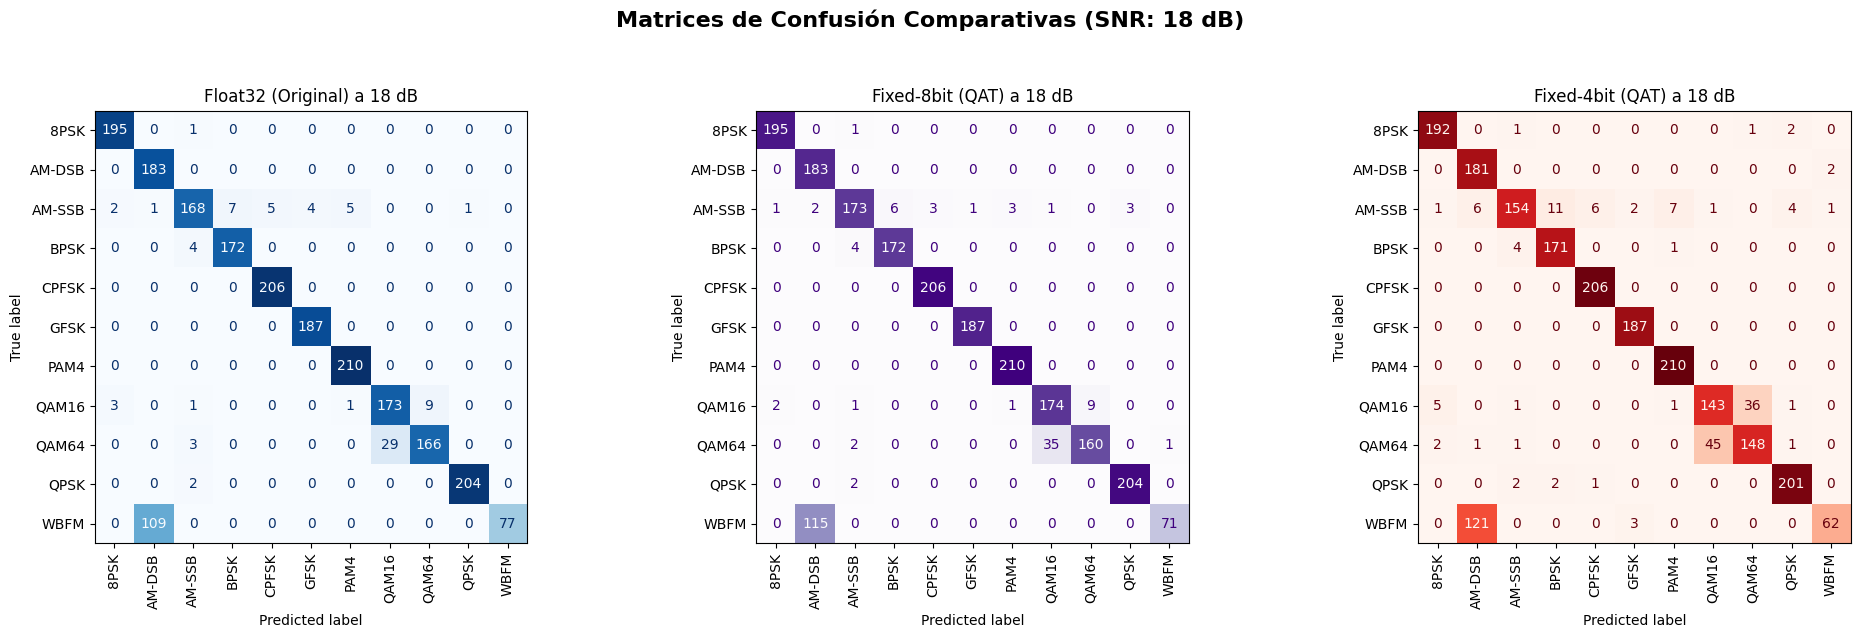

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ===========================================================================
# 0) SELECCIÓN DE SNR Y FILTRADO
# ===========================================================================
snr_seleccionado = 18 

print(f"Filtrando datos para SNR = {snr_seleccionado} dB...")
indices = np.where(snrs_test == snr_seleccionado)[0]

if len(indices) == 0:
    print(f"⚠️ No se encontraron señales con SNR = {snr_seleccionado} dB.")
else:
    X_test_snr = X_test_norm_reshaped[indices]
    Y_test_snr = Y_test_num[indices]

    print(f"Generando predicciones sobre {len(indices)} muestras...")

    # ===========================================================================
    # 1) OBTENER PREDICCIONES SOLO PARA ESTE SNR
    # ===========================================================================
    y_pred_32b_prob = original_model.predict(X_test_snr, verbose=0)
    y_pred_8b_prob  = qmodel.predict(X_test_snr, verbose=0)
    y_pred_4b_prob  = qmodel_4b.predict(X_test_snr, verbose=0)

    # ===========================================================================
    # 2) CONVERTIR A ETIQUETAS
    # ===========================================================================
    y_pred_32b = np.argmax(y_pred_32b_prob, axis=1)
    y_pred_8b  = np.argmax(y_pred_8b_prob, axis=1)
    y_pred_4b  = np.argmax(y_pred_4b_prob, axis=1)

    # ===========================================================================
    # 3) CALCULAR MATRICES DE CONFUSIÓN
    # ===========================================================================
    cm_32b = confusion_matrix(Y_test_snr, y_pred_32b)
    cm_8b  = confusion_matrix(Y_test_snr, y_pred_8b)
    cm_4b  = confusion_matrix(Y_test_snr, y_pred_4b)

    # ===========================================================================
    # 4) GRAFICAR
    # ===========================================================================
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Matriz 1: Modelo Original (32 bits)
    disp_32 = ConfusionMatrixDisplay(confusion_matrix=cm_32b, display_labels=clases)
    disp_32.plot(ax=axes[0], cmap="Blues", xticks_rotation='vertical', colorbar=False)
    axes[0].set_title(f"Float32 (Original) a {snr_seleccionado} dB", fontsize=12)

    # Matriz 2: Modelo Cuantizado a 8 bits
    disp_8 = ConfusionMatrixDisplay(confusion_matrix=cm_8b, display_labels=clases)
    disp_8.plot(ax=axes[1], cmap="Purples", xticks_rotation='vertical', colorbar=False)
    axes[1].set_title(f"Fixed-8bit (QAT) a {snr_seleccionado} dB", fontsize=12)

    # Matriz 3: Modelo Cuantizado a 4 bits
    disp_4 = ConfusionMatrixDisplay(confusion_matrix=cm_4b, display_labels=clases)
    disp_4.plot(ax=axes[2], cmap="Reds", xticks_rotation='vertical', colorbar=False)
    axes[2].set_title(f"Fixed-4bit (QAT) a {snr_seleccionado} dB", fontsize=12)

    # Ajustes visuales generales
    plt.suptitle(f'Matrices de Confusión Comparativas (SNR: {snr_seleccionado} dB)', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()